<a href="https://colab.research.google.com/github/Yash19815/heart-disease-detection/blob/main/Heart_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")
df = pd.read_csv(path+ '/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [16]:
df = df.rename(columns={'cp': 'Chest Pain', 'trestbps': 'Restibg BP', 'chol': 'cholestoral ', 'fbs': 'fasting blood sugar','thalach':'maximum heart rate'})

In [17]:
df.head()

,age,sex,Chest Pain,Restibg BP,cholestoral,fasting blood sugar,restecg,maximum heart rate,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


According to dataset info 0 meanes no disease and 1 means disease
in sex 0 means female and 1 means male

<Figure size 400x600 with 0 Axes>

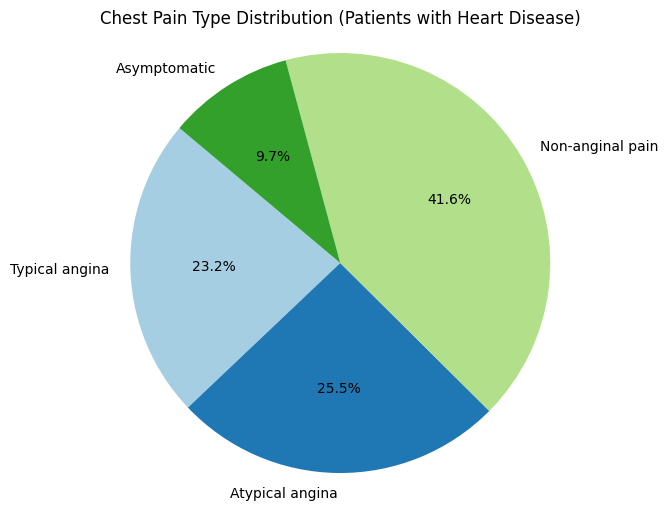

In [18]:
plt.figure(figsize=(4,6))
heart_disease_patients = df[df['target'] == 1]
cp_counts = heart_disease_patients['Chest Pain'].value_counts().sort_index()
cp_labels = {
    0: 'Typical angina',
    1: 'Atypical angina',
    2: 'Non-anginal pain',
    3: 'Asymptomatic'
}
labels = [cp_labels[i] for i in cp_counts.index]

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(cp_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Chest Pain Type Distribution (Patients with Heart Disease)')
plt.axis('equal')
plt.show()

In [20]:
X = df.drop(columns='target', axis=1)
Y = df['target']

In [21]:
print(Y)

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64


In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.8, stratify=Y, random_state=2)
print(X.shape, X_train.shape, X_test.shape)

(1025, 13) (205, 13) (820, 13)


# Logistic Regression

In [24]:
model = LogisticRegression()
model.fit(X_train, Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [40]:
def score(a,b):
  print(accuracy_score(a,b))
  print(classification_report(a,b))
  print(confusion_matrix(a,b))
  print(roc_auc_score(a,b))

In [45]:
X_train_prediction = model.predict(X_test)

In [46]:
score(X_train_prediction, Y_test)

0.8439024390243902
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       395
           1       0.85      0.84      0.85       425

    accuracy                           0.84       820
   macro avg       0.84      0.84      0.84       820
weighted avg       0.84      0.84      0.84       820

[[333  62]
 [ 66 359]]
0.8438719285182428


# RandomForest


In [52]:
rnd = RandomForestClassifier(max_depth=2, random_state=0)
rnd.fit(X_train, Y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [53]:
predict = rnd.predict(X_test)

In [54]:
score(predict, Y_test)

0.8426829268292683
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       404
           1       0.84      0.85      0.85       416

    accuracy                           0.84       820
   macro avg       0.84      0.84      0.84       820
weighted avg       0.84      0.84      0.84       820

[[337  67]
 [ 62 354]]
0.8425599771515612


In [56]:
train_acc = []
test_acc = []
depths = range(1, 16)

for depth in depths:
    dt_temp = RandomForestClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, Y_train)
    test_acc.append(dt_temp.score(X_test, Y_test))
    train_acc.append(dt_temp.score(X_train, Y_train))


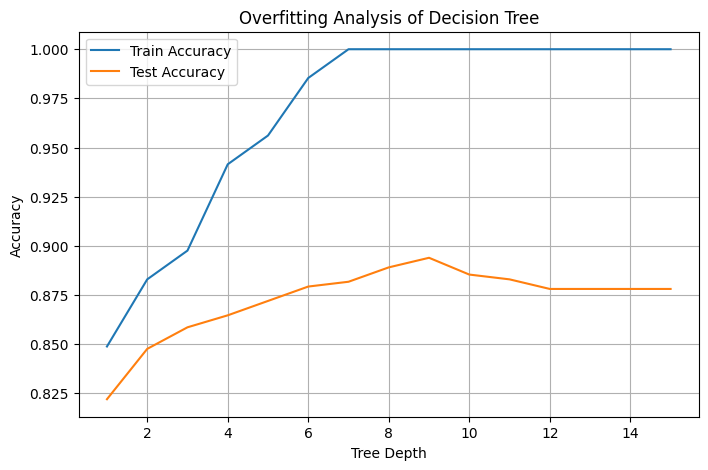

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(depths, train_acc, label='Train Accuracy')
plt.plot(depths, test_acc, label='Test Accuracy')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis of Decision Tree")
plt.legend()
plt.grid(True)
plt.show()

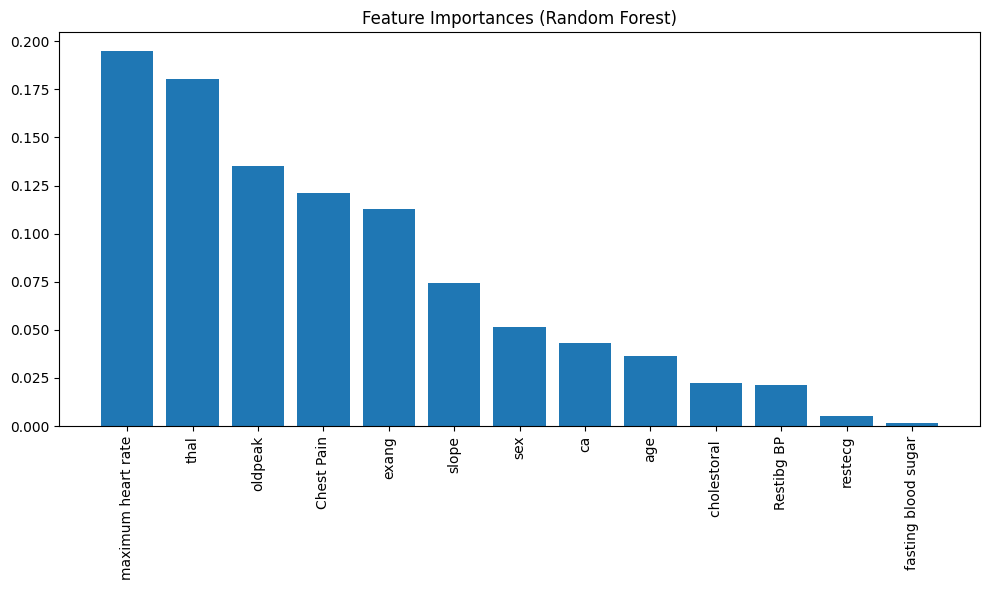

In [59]:
importances = rnd.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()